In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from scipy.sparse import hstack, csr_matrix

#Data Loading

In [9]:
df_recipes = pd.read_csv('RAW_recipes.csv')
df_interactions = pd.read_csv('RAW_interactions.csv')

print("Recipe Data Sample:")
print(df_recipes.head(3))

df_clean = df_recipes.drop(721).copy() if 721 in df_recipes.index else df_recipes.copy()

Recipe Data Sample:
                                         name      id  minutes  \
0  arriba   baked winter squash mexican style  137739       55   
1            a bit different  breakfast pizza   31490       30   
2                   all in the kitchen  chili  112140      130   

   contributor_id   submitted  \
0           47892  2005-09-16   
1           26278  2002-06-17   
2          196586  2005-02-25   

                                                tags  \
0  ['60-minutes-or-less', 'time-to-make', 'course...   
1  ['30-minutes-or-less', 'time-to-make', 'course...   
2  ['time-to-make', 'course', 'preparation', 'mai...   

                                    nutrition  n_steps  \
0       [51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]       11   
1   [173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]        9   
2  [269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]        6   

                                               steps  \
0  ['make a choice and proceed with recipe', 'dep...   
1  ['preheat

#Data Preprocessing & Feature Engineering

In [11]:
# Clean and split ingredients
new_ingredients = [str(item).replace("'", "").replace("[", "").replace("]", "") for item in df_clean['ingredients']]
df_clean['ingredients'] = [s.split(', ') for s in new_ingredients]

# Parse nutrition column
df_clean['nutrition'] = df_clean['nutrition'].apply(ast.literal_eval)
df_clean["calories (#)"] = [float(sublist[0]) for sublist in df_clean['nutrition']]
df_clean["total fat (PDV)"] = [float(sublist[1]) for sublist in df_clean['nutrition']]
df_clean["sugar (PDV)"] = [float(sublist[2]) for sublist in df_clean['nutrition']]
df_clean["sodium (PDV)"] = [float(sublist[3]) for sublist in df_clean['nutrition']]
df_clean["protein (PDV)"] = [float(sublist[4]) for sublist in df_clean['nutrition']]
df_clean["saturated fat (PDV)"] = [float(sublist[5]) for sublist in df_clean['nutrition']]
df_clean["carbohydrates (PDV)"] = [float(sublist[6]) for sublist in df_clean['nutrition']]
df_clean = df_clean.drop('nutrition', axis=1)

# Add Ratings and Review Counts
reviews_sum = df_interactions.groupby('recipe_id').agg(
    rating_mean=('rating', 'mean'),
    rating_count=('rating', 'count')
).reset_index()

df_clean = pd.merge(df_clean, reviews_sum, left_on='id', right_on='recipe_id', how='left')
df_clean['rating_mean'] = df_clean['rating_mean'].fillna(0)
df_clean['rating_count'] = df_clean['rating_count'].fillna(0)

# Filter outliers based on nutritional limits
df_clean = df_clean[df_clean["total fat (PDV)"] <= 100]
df_clean = df_clean[df_clean["sugar (PDV)"] <= 100]
df_clean = df_clean[df_clean["sodium (PDV)"] <= 100]
df_clean = df_clean[df_clean["protein (PDV)"] <= 100]
df_clean = df_clean[df_clean["saturated fat (PDV)"] <= 100]
df_clean = df_clean[df_clean["carbohydrates (PDV)"] <= 100]
df_clean = df_clean[df_clean["calories (#)"] <= 3000]

# Filter out specific tags
df_clean = df_clean[~df_clean["tags"].apply(lambda x: "condiments-etc" in str(x))]
df_clean = df_clean[~df_clean["tags"].apply(lambda x: "beverages" in str(x))]
df_clean = df_clean[~df_clean["tags"].apply(lambda x: "salad-dressings" in str(x))]
df_clean = df_clean[~df_clean["tags"].apply(lambda x: "stocks" in str(x))]

# Calculate Bayesian Average
C = np.percentile(df_clean["rating_count"], 25)
m = np.mean(df_clean["rating_mean"])
df_clean["bayesian_avg"] = ((df_clean["rating_mean"] * df_clean["rating_count"]) + (C * m)) / (df_clean["rating_count"] + C)

# Define Health Labels
def get_health_label(row):
    if (row['sodium (PDV)'] >= 20) or \
       (row['sugar (PDV)'] >= 20) or \
       (row['saturated fat (PDV)'] >= 20):
        return 'Unhealthy'
    elif ((row['sodium (PDV)'] <= 5) and \
         (row['sugar (PDV)'] <= 5) and \
         (row['saturated fat (PDV)'] <= 5)) or \
         ((row['protein (PDV)'] >=20) and \
          (row['calories (#)'] <=400)):
        return 'Healthy'
    else:
        return 'Neutral'

df_clean['health_label'] = df_clean.apply(get_health_label, axis=1)
label_mapping = {'Unhealthy': 0, 'Neutral': 1, 'Healthy': 2}
df_clean['health_score'] = df_clean['health_label'].map(label_mapping)

# Normalize Ingredients
replacements = {
    "eggs": "egg",
    "garlic cloves": "garlic",
    "all-purpose flour": "flour",
    "tablesalt": "salt",
    "table salt": "salt",
    "butter, softened": "butter",
    "unsalted butter": "butter",
    "sugar": "granulated sugar",
    "white sugar": "granulated sugar"
}

def normalize_ingredients(ing_list):
    try:
        new_list = []
        for ing in ing_list:
            ing = ing.lower().strip()
            if ing in replacements:
                new_list.append(replacements[ing])
            else:
                new_list.append(ing)
        return list(set(new_list))
    except:
        return []

df_clean['clean_ingredients_list'] = df_clean['ingredients'].apply(normalize_ingredients)

# Calculate log of minutes
df_clean['log_min'] = np.log(df_clean['minutes'] + 1)
df_clean = df_clean[df_clean['log_min'] < 8]

#Exploratory Data Analysis

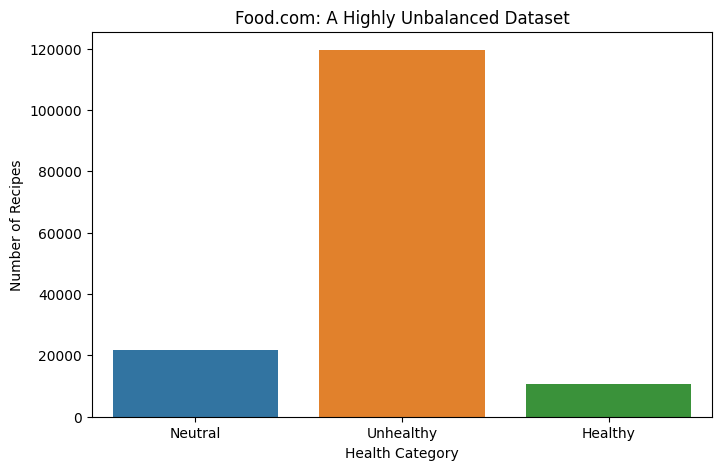

In [12]:
# Class Imbalance
plt.figure(figsize=(8, 5))
sns.countplot(x='health_label', hue='health_label', data=df_clean)
plt.title('Food.com: A Highly Unbalanced Dataset')
plt.xlabel('Health Category')
plt.ylabel('Number of Recipes')
plt.show()

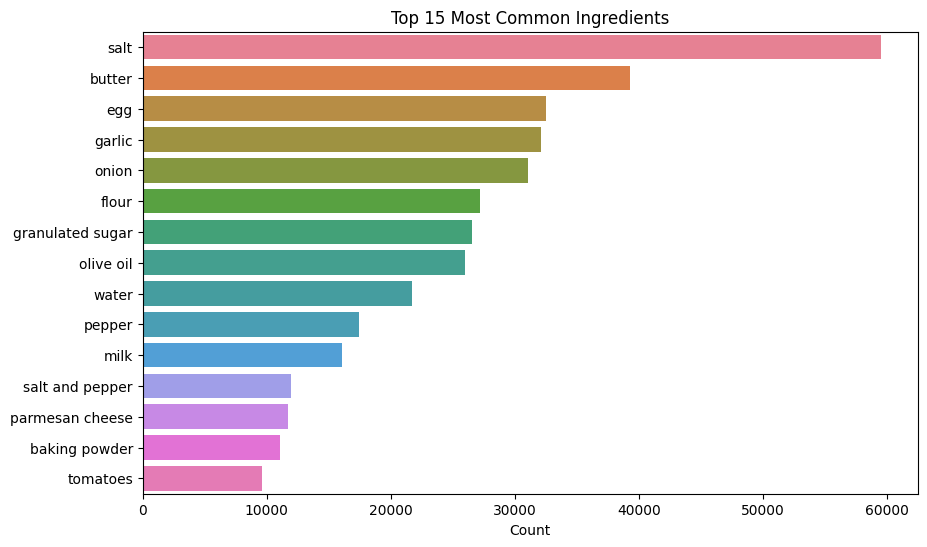

In [13]:
#Top 15 Ingredients
all_ingredients_final = [item for sublist in df_clean['clean_ingredients_list'] for item in sublist]
final_counts = Counter(all_ingredients_final)
top_ingredients = final_counts.most_common(15)
ing_names = [x[0] for x in top_ingredients]
ing_counts = [x[1] for x in top_ingredients]

plt.figure(figsize=(10, 6))
sns.barplot(x=ing_counts, y=ing_names, hue=ing_names)
plt.title('Top 15 Most Common Ingredients')
plt.xlabel('Count')
plt.show()

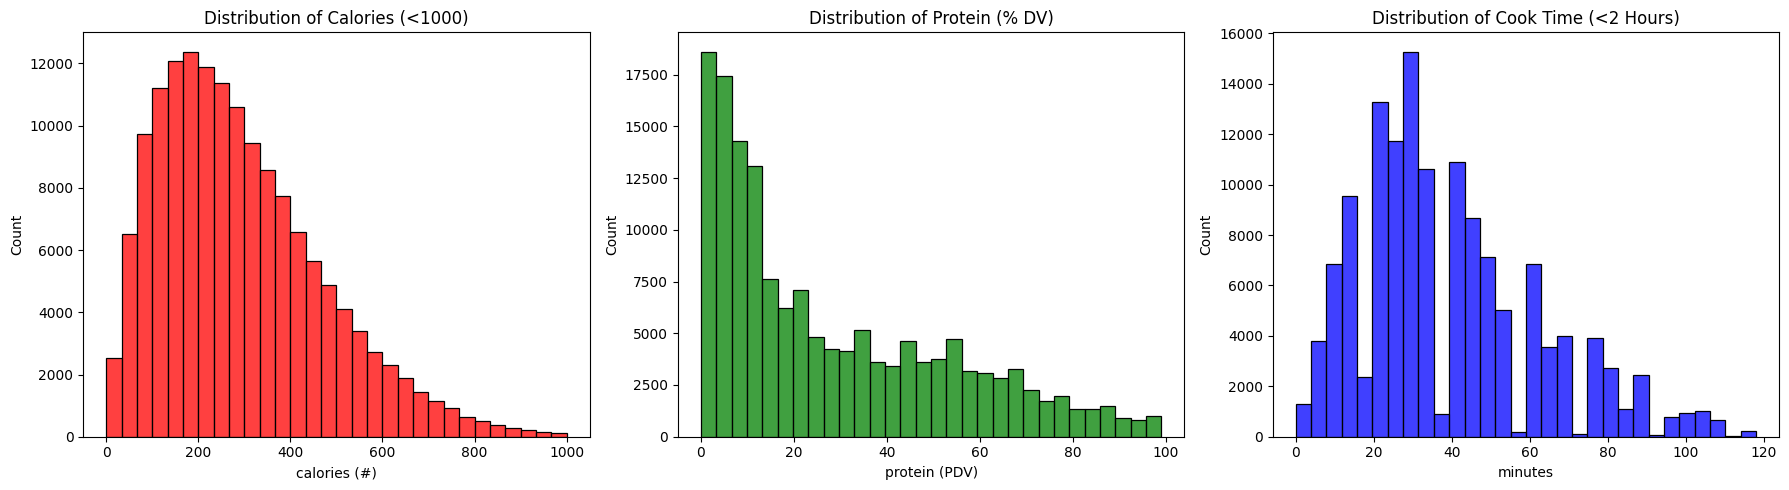

In [14]:
# Distribution of Key Variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_clean[df_clean['calories (#)'] < 1000]['calories (#)'], bins=30, ax=axes[0], color='red')
axes[0].set_title('Distribution of Calories (<1000)')

sns.histplot(df_clean[df_clean['protein (PDV)'] < 100]['protein (PDV)'], bins=30, ax=axes[1], color='green')
axes[1].set_title('Distribution of Protein (% DV)')

sns.histplot(df_clean[df_clean['minutes'] < 120]['minutes'], bins=30, ax=axes[2], color='blue')
axes[2].set_title('Distribution of Cook Time (<2 Hours)')
plt.tight_layout()
plt.show()

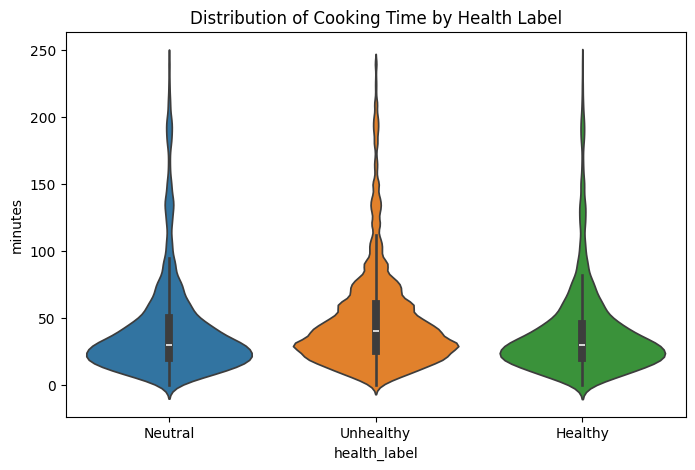

In [16]:
# Cooking Time & Complexity Violins
plot_df = df_clean[df_clean['minutes'] <= 240].copy()

plt.figure(figsize=(8, 5))
sns.violinplot(x='health_label', y='minutes', hue='health_label', data=plot_df)
plt.title('Distribution of Cooking Time by Health Label')
plt.show()

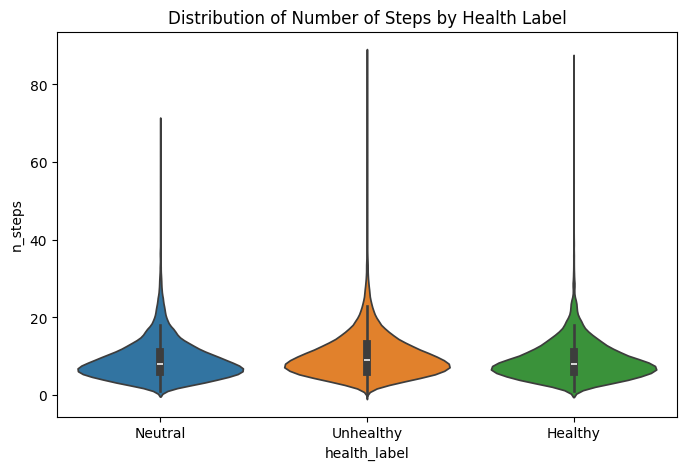

In [17]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='health_label', y='n_steps', hue='health_label', data=plot_df)
plt.title('Distribution of Number of Steps by Health Label')
plt.show()

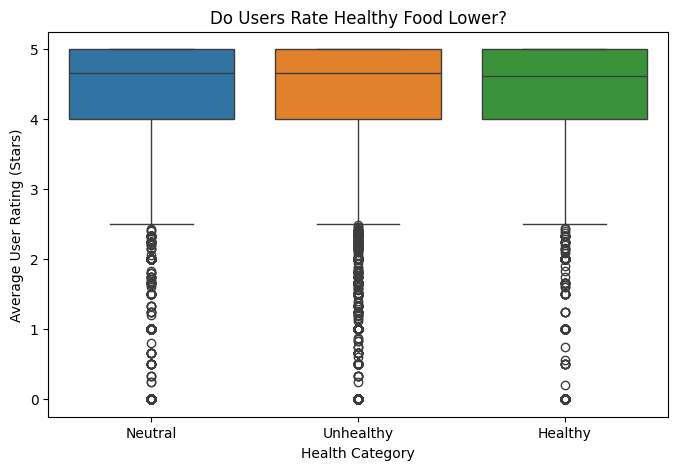

In [18]:
# Health Label vs. Rating
plt.figure(figsize=(8, 5))
sns.boxplot(x='health_label', y='rating_mean', hue='health_label', data=df_clean)
plt.title('Do Users Rate Healthy Food Lower?')
plt.ylabel('Average User Rating (Stars)')
plt.xlabel('Health Category')
plt.show()

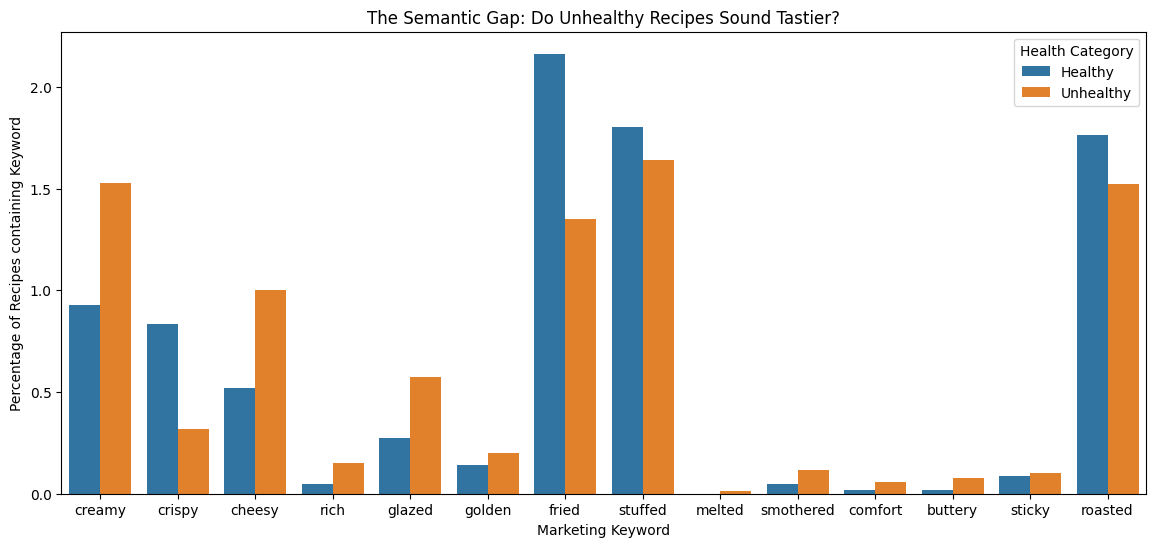

In [19]:
# Semantic Gap Analysis
hedonic_keywords = [
    'creamy', 'crispy', 'cheesy', 'rich', 'glazed',
    'golden', 'fried', 'stuffed', 'melted', 'smothered',
    'comfort', 'buttery', 'sticky', 'roasted'
]

def calculate_word_freq(df, label):
    results = []
    total_count = len(df)
    if total_count == 0:
        return pd.DataFrame()
    for word in hedonic_keywords:
        count = df['name'].astype(str).str.contains(word, case=False).sum()
        pct = (count / total_count) * 100
        results.append({'Keyword': word, 'Frequency (%)': pct, 'Group': label})
    return pd.DataFrame(results)

healthy_stats = calculate_word_freq(df_clean[df_clean['health_label'] == 'Healthy'], 'Healthy')
unhealthy_stats = calculate_word_freq(df_clean[df_clean['health_label'] == 'Unhealthy'], 'Unhealthy')
marketing_df = pd.concat([healthy_stats, unhealthy_stats])

plt.figure(figsize=(14, 6))
sns.barplot(x='Keyword', y='Frequency (%)', hue='Group', data=marketing_df)
plt.title('The Semantic Gap: Do Unhealthy Recipes Sound Tastier?')
plt.ylabel('Percentage of Recipes containing Keyword')
plt.xlabel('Marketing Keyword')
plt.legend(title='Health Category')
plt.show()

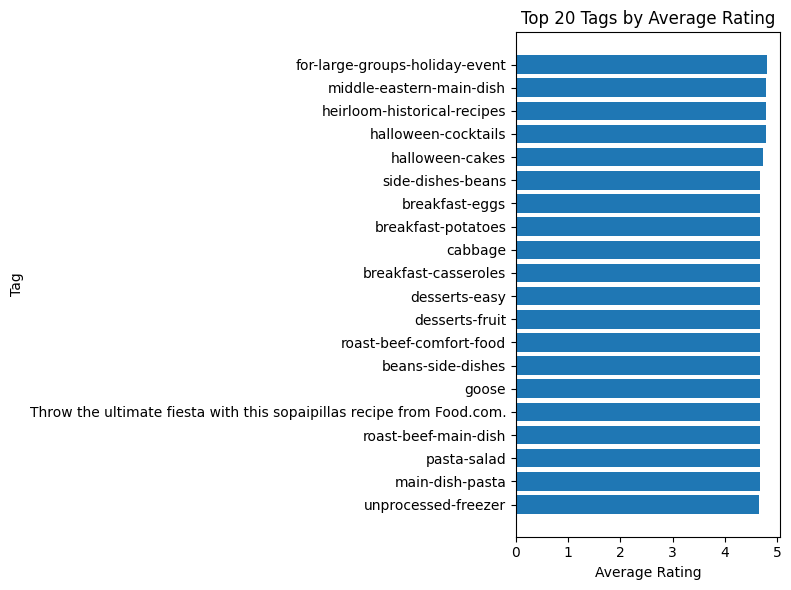

In [20]:
# Top 20 Tags by Bayesian Average
def fix_tags(x):
    if isinstance(x, str):
        try:
            return ast.literal_eval(x)
        except:
            return []
    return x

df_clean["tag_list"] = df_clean["tags"].apply(fix_tags)
exploded = df_clean.explode("tag_list")
exploded = exploded[exploded["tag_list"].notna() & (exploded["tag_list"] != "")]

tag_stats = exploded.groupby("tag_list")["bayesian_avg"].mean().sort_values(ascending=False)
top_tags = tag_stats.head(20)

plt.figure(figsize=(8,6))
plt.barh(top_tags.index, top_tags.values)
plt.xlabel("Average Rating")
plt.ylabel("Tag")
plt.title("Top 20 Tags by Average Rating")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


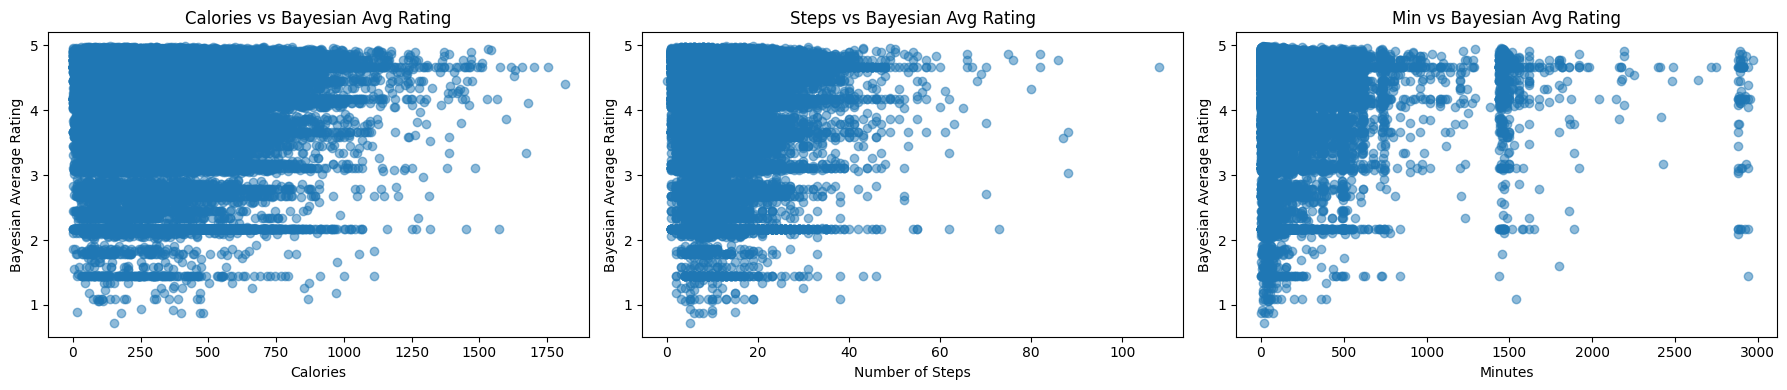

In [21]:
# Bayesian Average Scatter Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].scatter(df_clean["calories (#)"], df_clean["bayesian_avg"], alpha=0.5)
axes[0].set_xlabel("Calories")
axes[0].set_ylabel("Bayesian Average Rating")
axes[0].set_title("Calories vs Bayesian Avg Rating")

axes[1].scatter(df_clean["n_steps"], df_clean["bayesian_avg"], alpha=0.5)
axes[1].set_xlabel("Number of Steps")
axes[1].set_ylabel("Bayesian Average Rating")
axes[1].set_title("Steps vs Bayesian Avg Rating")

axes[2].scatter(df_clean["minutes"], df_clean["bayesian_avg"], alpha=0.5)
axes[2].set_xlabel("Minutes")
axes[2].set_ylabel("Bayesian Average Rating")
axes[2].set_title("Min vs Bayesian Avg Rating")
plt.tight_layout()
plt.show()

#Modeling (Rating Prediction)

In [22]:
# Filter for recipes with enough ratings to be reliable targets
df_model = df_clean[df_clean['rating_count'] >= 5].copy()

# Add interaction features
df_model['minutes_x_calories'] = df_model['minutes'] * df_model['calories (#)']
df_model['salt_x_sugar'] = df_model['sugar (PDV)'] * df_model['sodium (PDV)']
df_model['sugar_x_fat'] = df_model['sugar (PDV)'] * df_model['total fat (PDV)']
df_model['ingredients_x_steps'] = df_model['n_ingredients'] * df_model['n_steps']

# Prepare numeric features
numeric_cols = [
    "minutes", "calories (#)", "total fat (PDV)", "sugar (PDV)", "sodium (PDV)",
    "protein (PDV)", "saturated fat (PDV)", "carbohydrates (PDV)", "n_steps", "n_ingredients", "rating_count",
    "minutes_x_calories", "salt_x_sugar", "sugar_x_fat", "ingredients_x_steps"
]

X_num = df_model[numeric_cols].fillna(0).to_numpy()
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)
X_num_sparse = csr_matrix(X_num_scaled)

# Prepare text features (TF-IDF on the cleaned ingredient lists)
tfidf = TfidfVectorizer(tokenizer=lambda x: x, lowercase=False, max_features=1000)
ingredient_strings = df_model['clean_ingredients_list'].apply(lambda x: ' '.join(x))
X_ing = tfidf.fit_transform(ingredient_strings)

# Combine features
X = hstack([X_num_sparse, X_ing])
y = df_model["rating_mean"].to_numpy()

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


#Random Forest

Random Forest - Test RMSE: 0.512, MAE: 0.379, R^2: 0.029


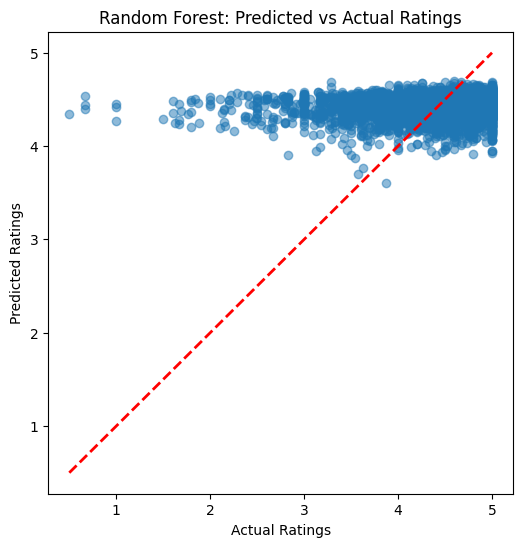

In [23]:
rfmodel = RandomForestRegressor(n_estimators=100, max_depth=15, n_jobs=-1, random_state=42)
rfmodel.fit(X_train, y_train)
rf_y_pred = rfmodel.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))
rf_mae = np.mean(np.abs(y_test - rf_y_pred))
rf_r2 = r2_score(y_test, rf_y_pred)
print(f"Random Forest - Test RMSE: {rf_rmse:.3f}, MAE: {rf_mae:.3f}, R^2: {rf_r2:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Random Forest: Predicted vs Actual Ratings")
plt.show()

#Stochastic Gradient Descent Regressor

SGD - Test RMSE: 0.530, MAE: 0.391, R^2: -0.043


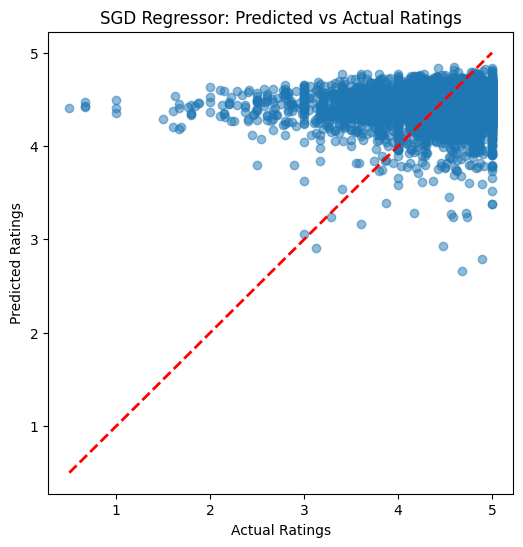

In [24]:
sgd_model = SGDRegressor(max_iter=1000, tol=1e-3, penalty='l2', random_state=42)
sgd_model.fit(X_train, y_train)
sgd_y_pred = sgd_model.predict(X_test)

sgd_rmse = np.sqrt(mean_squared_error(y_test, sgd_y_pred))
sgd_mae = np.mean(np.abs(y_test - sgd_y_pred))
sgd_r2 = r2_score(y_test, sgd_y_pred)
print(f"SGD - Test RMSE: {sgd_rmse:.3f}, MAE: {sgd_mae:.3f}, R^2: {sgd_r2:.3f}")

plt.figure(figsize=(6,6))
plt.scatter(y_test, sgd_y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("SGD Regressor: Predicted vs Actual Ratings")
plt.show()